# H1N1 subclade 频率预测曲线对比

本 notebook 在同一个预测截止点、同一组 14 天时间 bin 上重建所有现有频率预测模型的完整 subclade 概率曲线，并叠加真实频率。所有曲线均是条件频率，故每个模型在每个时间 bin 上的所有 subclade 频率之和为 1。

左列比较六个基础频率/计数模型；右列比较 C-B2、三种生物学校正和变点 softmax 模型。黑色实线是真实频率，彩色虚线是预测频率。

In [1]:
from pathlib import Path
from types import SimpleNamespace
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path('/home/chenyh/workspace/Alright-strain')
sys.path.insert(0, str(ROOT))

# 可改为 2023-03-31、2023-09-30、2024-03-31、2024-09-30、2025-03-31 或 2025-09-30。
# 生物学校正需要至少三个更早的窗口，因此不能使用更早的三个截止点。
FORECAST_CUTOFF = '2024-03-31'
TOP_N_BRANCHES = 5

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 30)


## 1. 在固定截止点重建预测概率轨迹

每个模型只使用截止点及以前的数据。生物学校正的系数只用更早的预测窗口拟合；变点模型会丢弃截止点后才出现的分支，因此不会把未来类别泄漏到预测状态中。

In [2]:
from src.h1n1_subclade_plot import read_nextclade_table
from src.h1n1_benchmarks import (
    DEFAULT_HALF_YEAR_WINDOWS,
    build_window_aligned_counts,
    evaluate_frequency_forecast,
    run_six_model_backtest,
)
from src.fitness.joint_forecast_demo import build_features, load_scored_sequences, ridge_predict
from src.fitness.c_b2_biological_correction_demo import (
    FEATURE_SETS, apply_correction, fit_correction, window_forecasts,
)
from src.model import ChangePointSoftmaxForecaster

nextclade_path = ROOT / 'data' / 'raw' / 'nextclade' / 'H1N1' / 'h1n1_results_MW626062_sorted.tsv'
records = read_nextclade_table(nextclade_path, label_mode='nextclade')
# 与 C-B2 生物学校正回测保持同一去重口径：仅保留唯一的 EPI_ISL 标识。
records['epi_isl'] = records['seqName'].astype('string').str.extract(r'\|(EPI_ISL_\d+)\|', expand=False)
records = records.loc[records['epi_isl'].notna() & ~records['epi_isl'].duplicated(keep=False)].copy()
window_map = {
    (pd.Timestamp(start) - pd.Timedelta(days=1)).date().isoformat(): (start, end)
    for start, end in sorted(DEFAULT_HALF_YEAR_WINDOWS[:-3])
}
if FORECAST_CUTOFF not in window_map:
    raise ValueError(f'FORECAST_CUTOFF 必须是以下之一：{list(window_map)}')
window_start, window_end = window_map[FORECAST_CUTOFF]
cutoff_time = pd.Timestamp(FORECAST_CUTOFF)
counts, _, horizon = build_window_aligned_counts(
    records, window_start=window_start, window_end=window_end
)
baseline_predictions, _, _, actual, _ = run_six_model_backtest(
    counts, cutoff=cutoff_time, horizon_bins=horizon
)

# 三种 C-B2 生物学校正：系数拟合只用当前截止点之前的窗口。
score_args = SimpleNamespace(
    scores_sqlite=ROOT / 'outputs' / 'h1n1_antigenicity' / 'antigenicity_scores.sqlite',
    query_instances_csv=ROOT / 'outputs' / 'h1n1_antigenicity' / 'input' / 'query_instances.csv',
    nextclade_tsv=nextclade_path,
    label_mode='nextclade',
)
scored, _ = load_scored_sequences(score_args)
cutoffs = pd.read_csv(ROOT / 'outputs' / 'h1n1_antigenicity' / 'panels' / 'forecast_cutoffs.csv')
features = build_features(scored, records, cutoffs, min_score_sequences=10)
biological_windows = window_forecasts(records, features, trajectory_mode='relative_fitness')
test_index = next(i for i, item in enumerate(biological_windows) if item.cutoff == FORECAST_CUTOFF)
if test_index < 3:
    raise ValueError('该截止点没有足够的早期窗口来无泄漏拟合生物学校正。')
test_window = biological_windows[test_index]
train_windows = biological_windows[:test_index]

predictions = {
    name: frame.reindex(index=actual.index, columns=actual.columns, fill_value=0.0)
    for name, frame in baseline_predictions.items()
}
for name, columns in FEATURE_SETS.items():
    if not columns:  # 与已有 C-B2 曲线重复
        continue
    weights, mean, scale = fit_correction(
        train_windows, columns, l2=1.0, objective='top1', trajectory_mode='relative_fitness'
    )
    predictions[name] = apply_correction(
        test_window, columns, weights, mean, scale, trajectory_mode='relative_fitness'
    ).reindex(index=actual.index, columns=actual.columns, fill_value=0.0)

# 独立的抗原性 + Fitness 联合 Ridge 模型。它原本预测六个月末的份额变化，
# 因而以下仅为绘图在概率单纯形上加入线性时间桥接，并非额外拟合时间动力学。
joint_train = features.loc[features.forecast_cutoff.lt(FORECAST_CUTOFF)].dropna(
    subset=['current_share', 'escape_excess', 'fitness_excess', 'share_change']
)
joint_test = features.loc[features.forecast_cutoff.eq(FORECAST_CUTOFF)].dropna(
    subset=['current_share', 'escape_excess', 'fitness_excess']
).copy()
if joint_test.empty:
    raise RuntimeError('联合 Ridge 模型在此截止点没有可用的分支特征。')
joint_test['predicted_share_change'] = ridge_predict(joint_train, joint_test, alpha=1.0)
cutoff_row = cutoffs.loc[cutoffs.forecast_cutoff.astype(str).eq(FORECAST_CUTOFF)].iloc[0]
recent_counts = records.loc[records.collection_date.between(
    cutoff_row.recent_start, cutoff_row.recent_end
), 'prediction_branch'].value_counts(normalize=True)
joint_start = recent_counts.reindex(actual.columns, fill_value=0.0)
joint_end = joint_start.copy()
joint_end.loc[joint_test.branch] = (
    joint_test.set_index('branch')['current_share'] + joint_test.set_index('branch')['predicted_share_change']
).clip(lower=0.0)
joint_end /= joint_end.sum()
bridge = pd.DataFrame(
    [(1 - weight) * joint_start + weight * joint_end for weight in range(1, len(actual) + 1)],
    index=actual.index, columns=actual.columns,
)
predictions['Joint antigenicity + Fitness (linear bridge)'] = bridge

competition_model = ChangePointSoftmaxForecaster()
predictions['Change-point softmax'] = competition_model.predict(
    counts.loc[counts.index <= cutoff_time], horizon=len(actual), future_index=actual.index
).reindex(columns=actual.columns, fill_value=0.0)

assert all(frame.index.equals(actual.index) for frame in predictions.values())
assert all((frame.sum(axis=1).sub(1).abs() < 1e-10).all() for frame in predictions.values())
print(f'Forecast cutoff: {FORECAST_CUTOFF}; evaluation: {actual.index.min().date()} to {actual.index.max().date()}; bins: {len(actual)}')
print('Change-point softmax diagnostics:', competition_model.last_diagnostics)


Forecast cutoff: 2024-03-31; evaluation: 2024-04-01 to 2024-09-16; bins: 13
Change-point softmax diagnostics: ForecastDiagnostics(lookback_start=Timestamp('2023-04-03 00:00:00'), change_point=Timestamp('2023-11-13 00:00:00'), regime_start=Timestamp('2023-11-13 00:00:00'), change_score=7.886739173363169, slope_norm=0.18, regime_bins=10)


## 2. 同一条真实轨迹上的误差比较

下表使用完整频率向量计算 TVD、JSD、MAE、RMSE；不是只看最终 bin 或最大分支。`Joint antigenicity + Fitness (linear bridge)` 的中间 bin 是为可视化而做的单纯形线性插值，因此其逐 bin 指标不应与原始的半年终点 Ridge 回测混为一谈。

In [3]:
curve_metrics = pd.DataFrame([
    {
        'model': name,
        **evaluate_frequency_forecast(actual, frame).to_dict(),
        'top1_accuracy': (frame.idxmax(axis=1) == actual.idxmax(axis=1)).mean(),
    }
    for name, frame in predictions.items()
]).sort_values('mean_TVD', ignore_index=True)
display(curve_metrics.style.format({
    'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'mean_TVD': '{:.4f}',
    'mean_JSD': '{:.4f}', 'top1_accuracy': '{:.1%}',
}))


,model,MAE,RMSE,mean_TVD,mean_JSD,top1_accuracy
0,C-B2 + relative fitness,0.0124,0.0388,0.2417,0.0936,100.0%
1,C-B2 + relative Fitness,0.0128,0.0360,0.2486,0.0909,100.0%
2,F-B2,0.0147,0.0409,0.2864,0.1123,100.0%
3,C-B2 + relative antigenicity,0.0158,0.0459,0.3084,0.1052,61.5%
4,C-B2,0.0164,0.0478,0.3195,0.1077,61.5%
5,Change-point softmax,0.0178,0.0421,0.3472,0.1223,100.0%
6,F-B0,0.0191,0.0438,0.3716,0.1322,100.0%
7,C-B0,0.0191,0.0438,0.3716,0.1322,100.0%
8,C-B1,0.0209,0.0535,0.4080,0.1947,100.0%
9,F-B1,0.0244,0.0538,0.4749,0.1940,100.0%


## 3. 逐 subclade 的预测曲线与真实曲线

展示真实轨迹中峰值最高的 `TOP_N_BRANCHES` 个 subclade。每一行是一个 subclade；左、右面板共享纵轴，便于读取同一模型在连续多个 bin 上的动态偏差。

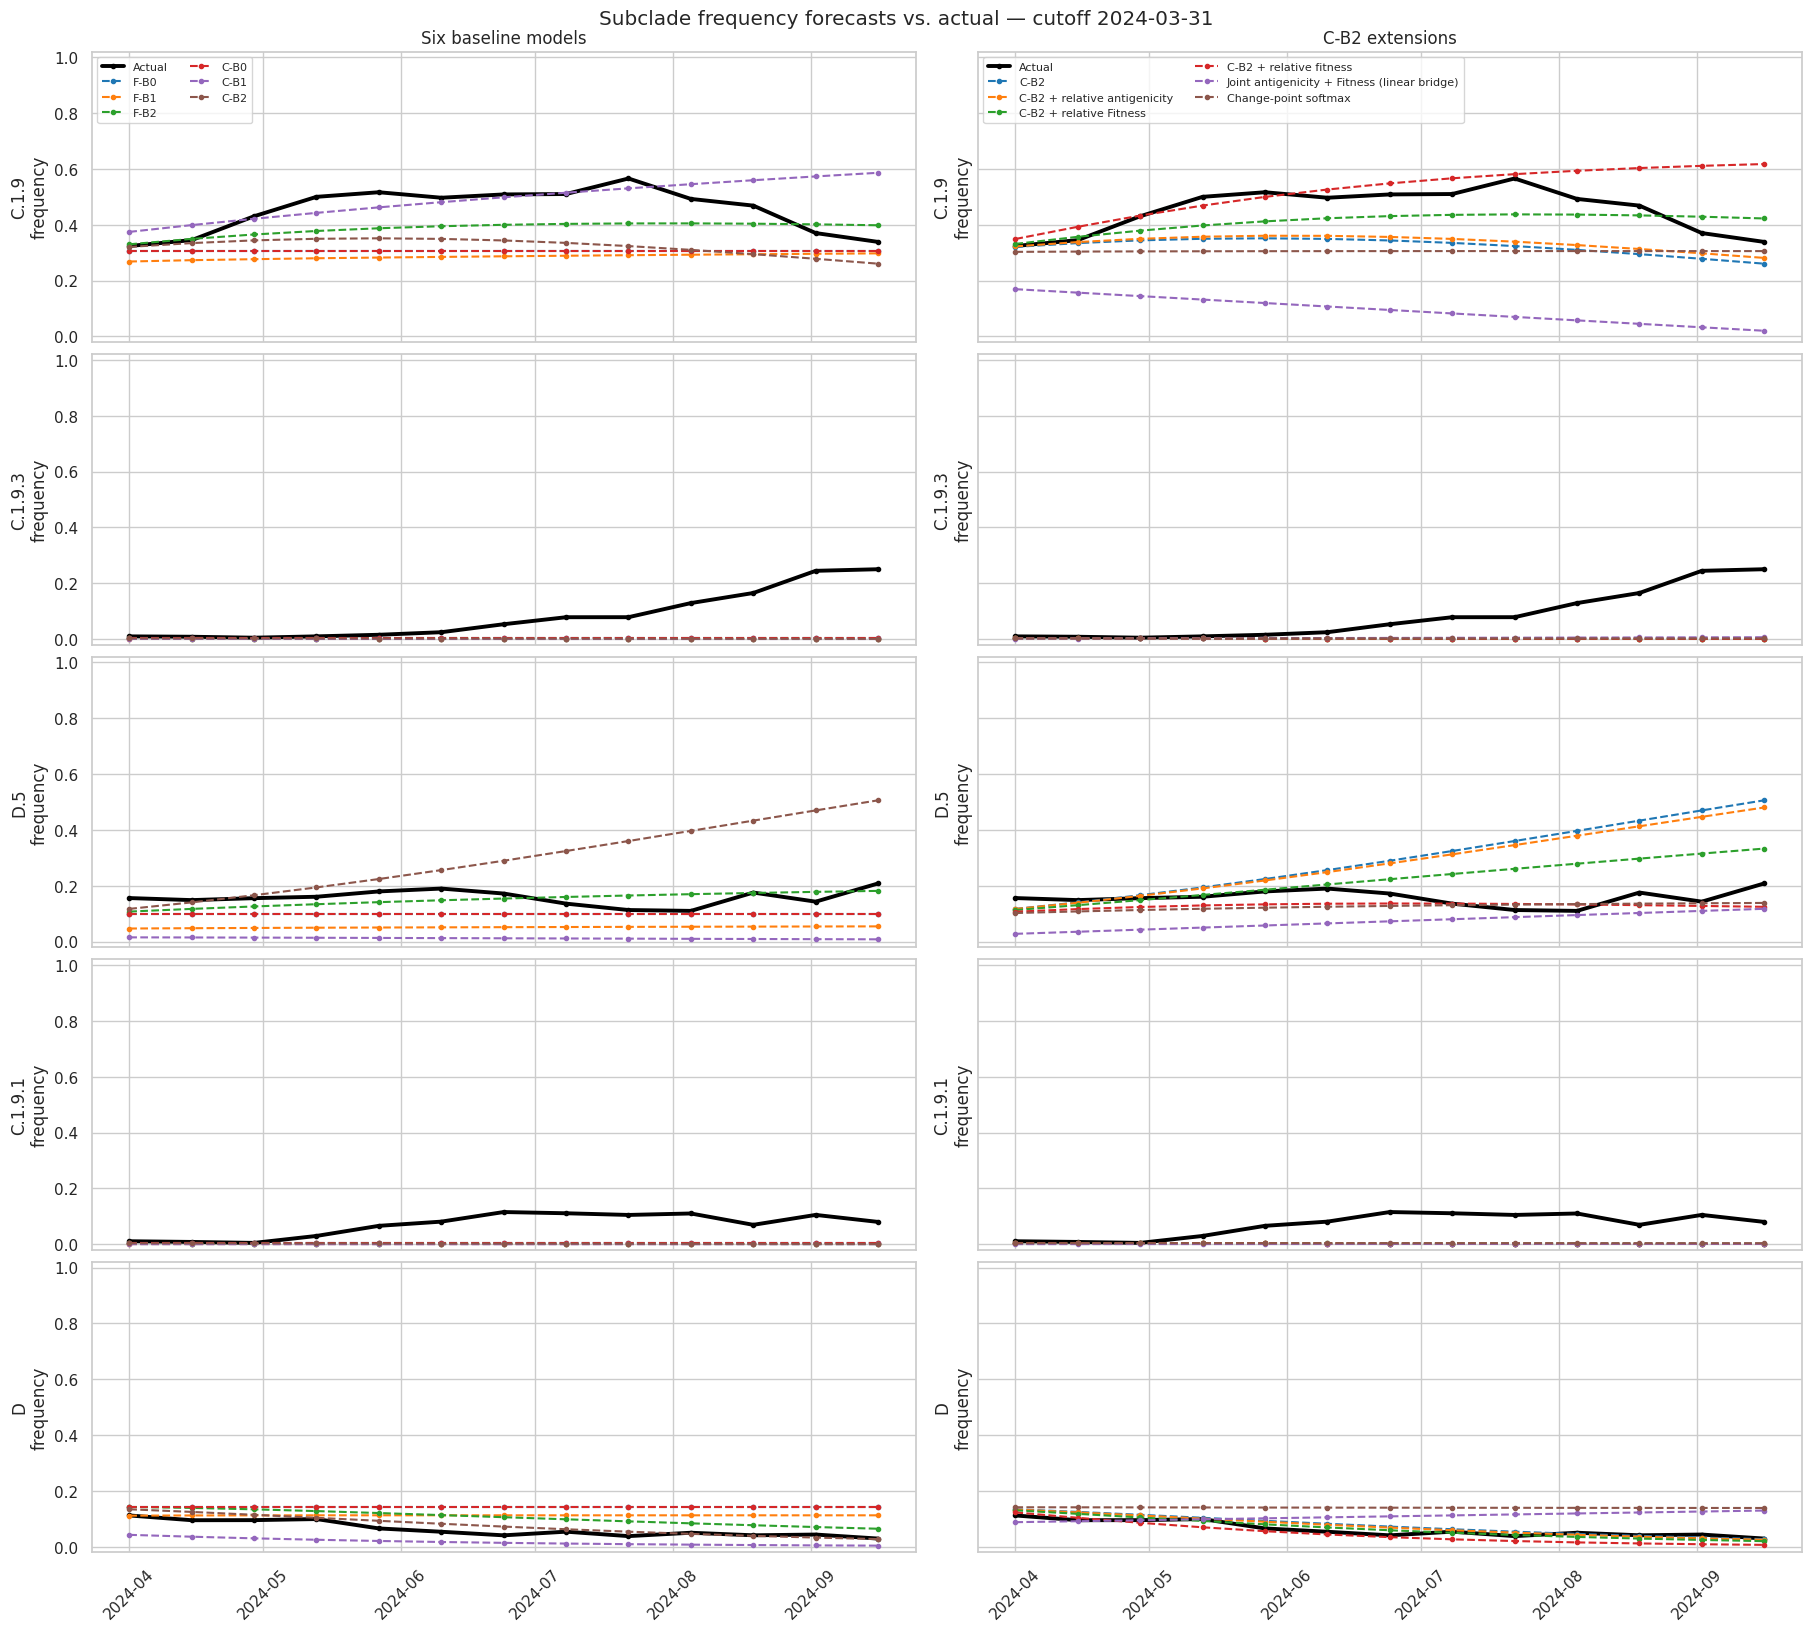

,peak_actual_frequency,mean_actual_frequency
prediction_branch,,
C.1.9,56.6%,45.1%
C.1.9.3,25.0%,8.2%
D.5,20.8%,15.8%
C.1.9.1,11.5%,6.9%
D,11.2%,6.3%


In [4]:
BASELINE_MODELS = ['F-B0', 'F-B1', 'F-B2', 'C-B0', 'C-B1', 'C-B2']
EXTENDED_MODELS = [
    'C-B2', 'C-B2 + relative antigenicity', 'C-B2 + relative Fitness',
    'C-B2 + relative fitness', 'Joint antigenicity + Fitness (linear bridge)',
    'Change-point softmax',
]
branches = actual.max().sort_values(ascending=False).head(TOP_N_BRANCHES).index.tolist()

fig, axes = plt.subplots(
    len(branches), 2, figsize=(18, max(3.2 * len(branches), 5)), sharex=True, sharey=True, constrained_layout=True
)
if len(branches) == 1:
    axes = axes.reshape(1, 2)
groups = [('Six baseline models', BASELINE_MODELS), ('C-B2 extensions', EXTENDED_MODELS)]
for row, branch in enumerate(branches):
    for column, (title, model_names) in enumerate(groups):
        ax = axes[row, column]
        palette = sns.color_palette('tab10', len(model_names))
        ax.plot(actual.index, actual[branch], color='black', linewidth=2.8, marker='o', markersize=3, label='Actual')
        for color, name in zip(palette, model_names):
            ax.plot(actual.index, predictions[name][branch], color=color, linewidth=1.5, linestyle='--', marker='.', label=name)
        ax.set_ylim(-0.02, 1.02)
        ax.set_ylabel(f'{branch}\nfrequency')
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.tick_params(axis='x', rotation=45)
        if row == 0:
            ax.set_title(title)
            ax.legend(fontsize=8, ncol=2, loc='upper left')
fig.suptitle(f'Subclade frequency forecasts vs. actual — cutoff {FORECAST_CUTOFF}', y=1.01)
plt.show()

display(pd.DataFrame({'peak_actual_frequency': actual[branches].max(), 'mean_actual_frequency': actual[branches].mean()})
        .sort_values('peak_actual_frequency', ascending=False)
        .style.format('{:.1%}'))


## 4. C-B2 在全部滚动窗口的预测曲线与真实曲线

每个面板是一个半年预测窗口。颜色区分该窗口真实频率峰值最高的 subclade；同色实线为真实频率、虚线为 C-B2 预测频率。面板角落的 TVD 使用该窗口的完整分支分布计算，而不只限于图中显示的分支。

In [ ]:
from matplotlib.lines import Line2D

WINDOW_TOP_N = 4
window_specs = sorted(DEFAULT_HALF_YEAR_WINDOWS[:-3])
ncols = 3
nrows = (len(window_specs) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4.8 * nrows), sharey=True, constrained_layout=True)
axes = axes.ravel()
c_b2_window_metrics = []

for axis, (window_start, window_end) in zip(axes, window_specs):
    window_counts, _, window_horizon = build_window_aligned_counts(
        records, window_start=window_start, window_end=window_end
    )
    window_cutoff = pd.Timestamp(window_start) - pd.Timedelta(days=1)
    window_predictions, _, _, window_actual, _ = run_six_model_backtest(
        window_counts, cutoff=window_cutoff, horizon_bins=window_horizon
    )
    window_c_b2 = window_predictions['C-B2'].reindex(
        index=window_actual.index, columns=window_actual.columns, fill_value=0.0
    )
    window_tvd = evaluate_frequency_forecast(window_actual, window_c_b2)['mean_TVD']
    c_b2_window_metrics.append({
        'forecast_cutoff': window_cutoff.date().isoformat(),
        'evaluation_start': window_actual.index.min().date(),
        'evaluation_end': window_actual.index.max().date(),
        'mean_TVD': window_tvd,
        'top1_accuracy': (window_c_b2.idxmax(axis=1) == window_actual.idxmax(axis=1)).mean(),
    })
    window_branches = window_actual.max().sort_values(ascending=False).head(WINDOW_TOP_N).index
    colors = sns.color_palette('tab10', len(window_branches))
    for color, branch in zip(colors, window_branches):
        axis.plot(window_actual.index, window_actual[branch], color=color, linewidth=2.4, label=branch)
        axis.plot(window_c_b2.index, window_c_b2[branch], color=color, linewidth=1.7, linestyle='--')
    axis.set_title(f'Cutoff {window_cutoff.date()}  |  TVD = {window_tvd:.3f}')
    axis.set_ylim(-0.02, 1.02)
    axis.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axis.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axis.tick_params(axis='x', rotation=45)
    axis.legend(title='Subclade', fontsize=8, title_fontsize=9, loc='upper left')

for axis in axes[len(window_specs):]:
    axis.set_visible(False)
for axis in axes[:len(window_specs)]:
    axis.set(xlabel='14-day bin', ylabel='Frequency')
fig.legend(
    handles=[
        Line2D([0], [0], color='black', linewidth=2.4, label='Actual'),
        Line2D([0], [0], color='black', linewidth=1.7, linestyle='--', label='C-B2 forecast'),
    ],
    loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.03), frameon=True,
)
fig.suptitle('C-B2 rolling forecasts versus observed subclade frequencies', y=1.01)
plt.show()

c_b2_window_metrics = pd.DataFrame(c_b2_window_metrics)
display(c_b2_window_metrics.style.format({'mean_TVD': '{:.4f}', 'top1_accuracy': '{:.1%}'}))
